<img align='center' style='max-width: 1000px' src='../banner.png'>

<img align='right' style='max-width: 200px; height: auto' src='../hsg_logo.png'>



## Lab 09 - Part 2: LSTM Time-Series Forecasting and Backtesting



Artificial Intelligence (Spring 2026), University of St. Gallen

In this part of the lab, we study how Long Short-Term Memory (LSTM) networks can be used to model sequential financial data. Financial time series are a natural application area for recurrent models because the next observation often depends not only on the most recent value, but also on the short-term temporal context that precedes it. Our goal is therefore to learn from a short history of daily stock returns and use that information to forecast the next return.



We will work with historical daily data of IBM stock and follow the complete prediction pipeline used in many time-series applications. First, we prepare the return series and convert it into rolling input sequences. Next, we load an LSTM model and use it to generate one-step-ahead forecasts. Finally, we interpret the predicted returns as trading signals and evaluate the resulting strategy in a backtest.



The figure below illustrates a high-level view on the machine learning process we aim to establish in this lab.



<img align='center' style='max-width: 700px' src='figures/process.png'>

Lab Objectives

1. Understand how daily stock prices can be transformed into returns and rolling sequences for sequence modeling.
2. Review the structure of an LSTM network used for one-step-ahead forecasting.
3. Evaluate the model on both in-sample and out-of-sample data.
4. Convert forecasts into long/short signals and compare the resulting strategy with a passive baseline.

## 1. Setup



We start by importing the libraries that will be used for data handling, modeling, visualization, and backtesting.



The next cell loads the standard scientific Python stack aswell as the `bt` backtesting library. Python `bt` is a flexible, backtest framework that can be used to test quantitative trading strategies. In general, backtesting is the process of testing a strategy over a given data set (more details about the `bt` library can be found via: https://pmorissette.github.io/bt/).

In [8]:
import warnings
warnings.filterwarnings('ignore')

import importlib.util
import os
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

def ensure_package(package_name):
    if importlib.util.find_spec(package_name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package_name])

ensure_package('bt')
import bt

plt.rcParams['figure.figsize'] = [14, 5]
plt.rcParams['figure.dpi'] = 140

We then define the locations of the dataset and checkpoint, select the computation device, and initialize the random seeds used in this notebook.

In [9]:
DATA_PATH = './data_lstm/ibm_data_2010_2017_daily.csv'
MODEL_PATH = './models_lstm/best_lstm_model.pth'
FALLBACK_MODEL_PATH = './models_lstm/best_lstm_model_80.pth'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(1234)
np.random.seed(1234)

print(f'Using device: {device}')
print(f'Data file exists: {os.path.exists(DATA_PATH)}')
print(f'Best checkpoint exists: {os.path.exists(MODEL_PATH)}')
print(f'Fallback checkpoint exists: {os.path.exists(FALLBACK_MODEL_PATH)}')

Using device: cpu
Data file exists: True
Best checkpoint exists: True
Fallback checkpoint exists: True


## 2. Load the IBM Stock Series

We begin by loading the historical IBM dataset from disk. For the forecasting task in this notebook, we focus on the closing price and derive daily percentage returns from it.

The next cell reads the CSV file, cleans the columns, keeps only the original trading days, and computes the return series that will later be used by the LSTM. This avoids introducing artificial zero-return observations from weekends and holidays.

In [10]:
raw_data = pd.read_csv(DATA_PATH, sep=';', header=[0, 1], skiprows=[2], index_col=0, parse_dates=True)
stock_data = raw_data.copy()
stock_data.columns = stock_data.columns.get_level_values(0)
stock_data = stock_data.sort_index().apply(pd.to_numeric, errors='coerce')
stock_data['RETURN'] = stock_data['Close'].pct_change()
stock_data[['Close', 'RETURN']].head()

Price,Close,RETURN
2000-01-03,56.671013,NaN
2000-01-04,54.747360,-0.033944
2000-01-05,56.671013,0.035137
2000-01-06,55.693943,-0.017241
2000-01-07,55.449677,-0.004386


After preparing the dataset, we visualize the closing price and the return series. This makes it easier to compare the smoother price trajectory with the more volatile return signal that the LSTM will model.

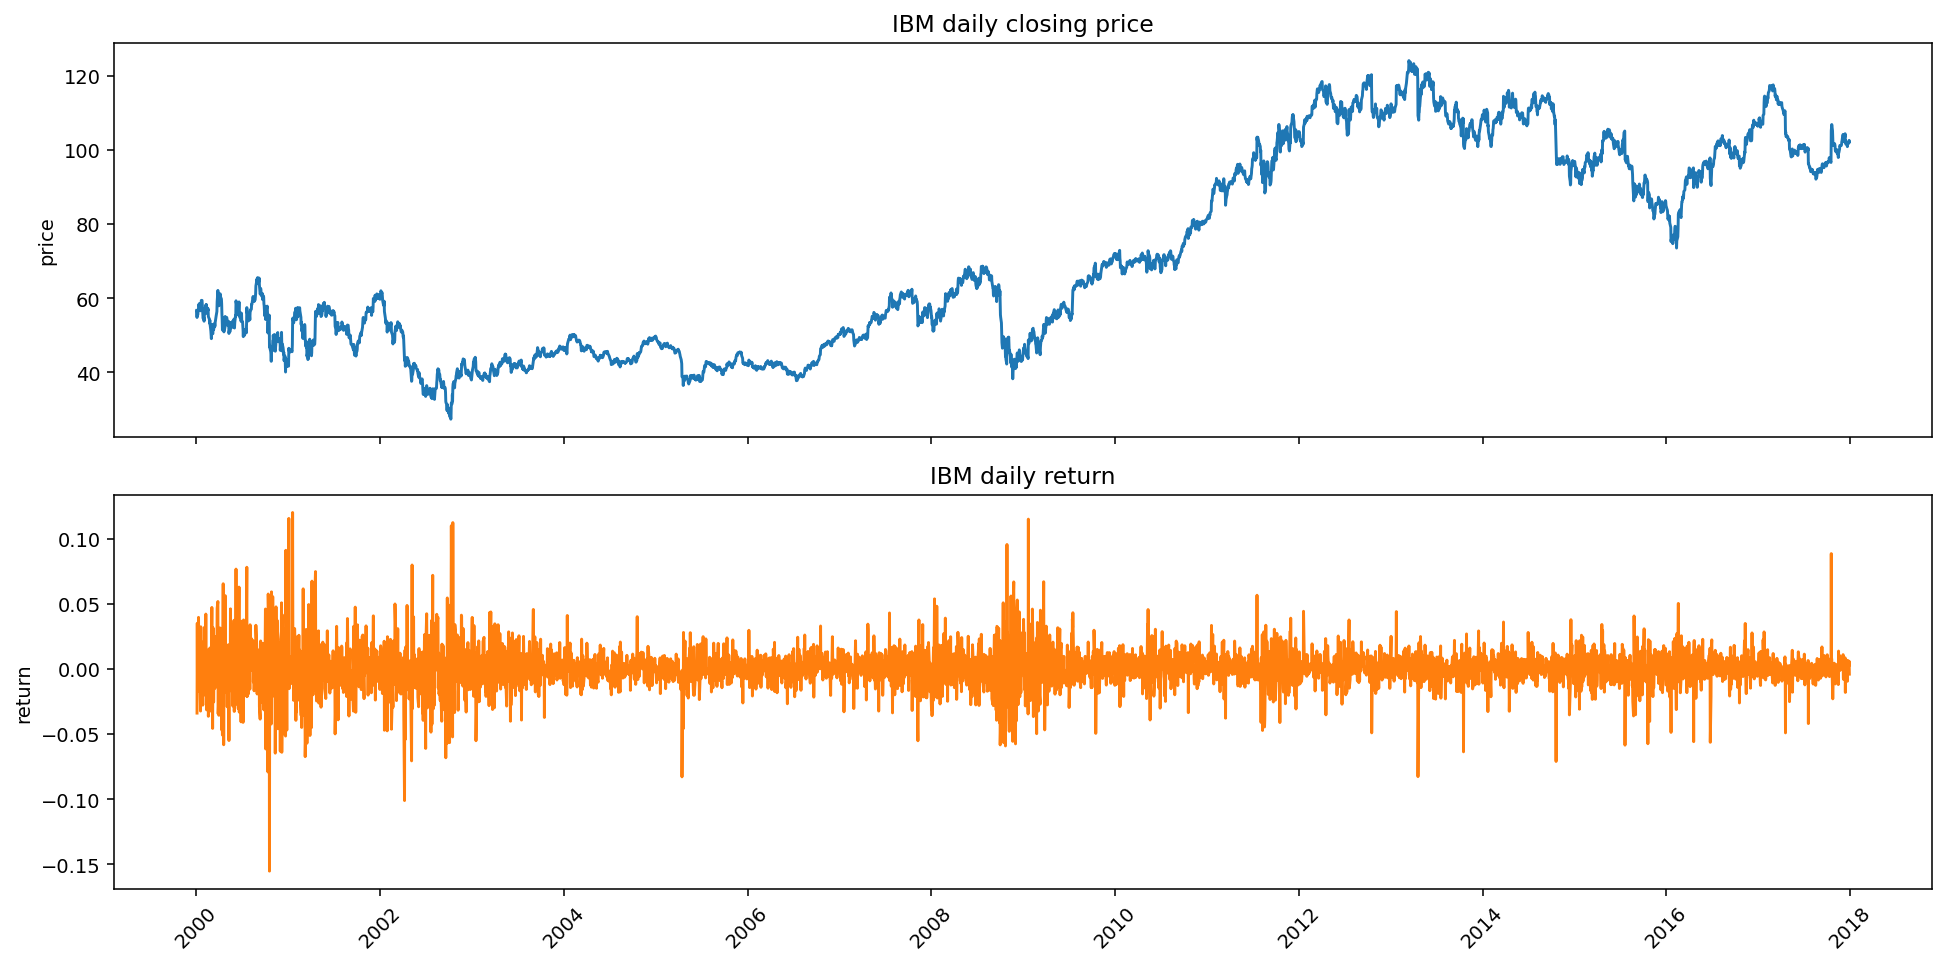

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(stock_data.index, stock_data['Close'], color='C0')
axes[0].set_title('IBM daily closing price')
axes[0].set_ylabel('price')

axes[1].plot(stock_data.index, stock_data['RETURN'], color='C1')
axes[1].set_title('IBM daily return')
axes[1].set_ylabel('return')

for tick in axes[1].get_xticklabels():
    tick.set_rotation(45)

plt.tight_layout()

## 3. Build Input Sequences



In the following, we determine the number of return time-steps $n$ each individual sequence $s^{i}$ should be comprised of. Each sequence is thereby determined by the number of predictor (return) time-steps $t$ and the prediction (return) horizon $h = t+1$.

<img align='center' style='max-width: 500px' src='figures/timesteps.png'>

In this example, we will set the number of predictor (return) time-steps to $t$=4. This indicates that the input sequence of each sample is a vector of 4 sequential daily stock returns (pls. note, the choice of $t$=4 is arbitrary and should be selected through experimentation). Furthermore, we set the predicted return horizon to 1, which specifies that we aim to forecast a single future time-step.

In [12]:
split_fraction = 0.9
time_steps, horizon = 4, 1
sequence_length = time_steps + horizon

split_row = int(len(stock_data) * split_fraction)
train_stock_data = stock_data.iloc[:split_row]
valid_stock_data = stock_data.iloc[split_row:]

print('Train rows:', len(train_stock_data))
print('Validation rows:', len(valid_stock_data))

Train rows: 4075
Validation rows: 453


Next, we extract the sequences $s^i$ of 5 time-steps. 

Thereby, we will step-wise iterate ("rolling window") over the entire sequence of daily stock returns $r_i$. In each iteration step, we extract an individual sequence of stock returns consisting of $n$ time-steps. The extracted individual sequences of daily closing prices are then collected in a single data frame.

<img align='center' style='max-width: 900px' src='figures/sequences.png'>

We define a helper function that extracts overlapping windows of dates and returns from a given split of the time series. Each window will later become one example for the LSTM.

In [13]:
def build_sequences(frame, sequence_length):
    max_start = ((len(frame) // sequence_length) - 1) * sequence_length
    dates = frame.index.to_numpy()
    returns = frame['RETURN'].to_numpy(dtype=np.float32)
    
    date_windows = [dates[i:i + sequence_length] for i in range(1, max_start)]
    value_windows = [returns[i:i + sequence_length] for i in range(1, max_start)]
    
    return np.array(date_windows), np.array(value_windows, dtype=np.float32)

Finally, we apply the helper to both splits and convert the resulting arrays into PyTorch tensors that can be passed to the model.

In [14]:
train_dates, train_sequences = build_sequences(train_stock_data, sequence_length)
valid_dates, valid_sequences = build_sequences(valid_stock_data, sequence_length)

train_inputs = torch.from_numpy(train_sequences[:, :-1]).float()
train_targets = torch.from_numpy(train_sequences[:, 1:]).float()
valid_inputs = torch.from_numpy(valid_sequences[:, :-1]).float()
valid_targets = torch.from_numpy(valid_sequences[:, 1:]).float()

print('Train input shape:', tuple(train_inputs.shape))
print('Validation input shape:', tuple(valid_inputs.shape))

Train input shape: (4069, 4)
Validation input shape: (444, 4)


## 4. Load the Pre-Trained LSTM



The forecasting model in this notebook is an LSTM network, which we name **'LSTMNet'**, consists in total of three layers. The first two layers correspond to LSTM cells, while the third layer corresponds to a fully-connected linear layer. 

Each LSTM layer consits of a LSTM cell exhibiting a hidden state of 51 dimensions. The third linear squeezes the 51 hidden state dimensions of the second LSTM cell into a single output dimension. The single output signal of the linear layer refers to the return of the next time-step predicted by the neural network. Please note, that the choice of the implemented architecture and network hyperparameters is arbitrary and should in a real-world scenario be evaluated and selected thoroughly through experimentation.

<img align='center' style='max-width: 400px' src='figures/lstmnet.png'>

In [15]:
class LSTMNet(nn.Module):
    
    def __init__(self, hidden_size=51):
        super().__init__()
        self.hidden_size = hidden_size
        
        self.lstm1 = nn.LSTMCell(1, hidden_size)
        self.lstm2 = nn.LSTMCell(hidden_size, hidden_size)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, inputs):
        predictions = []
        
        h_t1 = h_t2 = torch.zeros(inputs.size(0), self.hidden_size, dtype=torch.float32, device=inputs.device)
        c_t1 = c_t2 = torch.zeros(inputs.size(0), self.hidden_size, dtype=torch.float32, device=inputs.device)
        
        for input_t in inputs.chunk(inputs.size(1), dim=1):
            
            h_t1, c_t1 = self.lstm1(input_t, (h_t1, c_t1))
            h_t2, c_t2 = self.lstm2(h_t1, (h_t2, c_t2))
            prediction = self.linear(h_t2)
            
            predictions.append(prediction)
            
        return torch.stack(predictions, dim=1).squeeze(-1)

With the architecture in place, we can now instantiate the network, load the checkpoint parameters, switch the model to evaluation mode, and inspect its size.

In [16]:
checkpoint_path = MODEL_PATH if os.path.exists(MODEL_PATH) else FALLBACK_MODEL_PATH
state_dict = torch.load(checkpoint_path, map_location=device)
lstm_model = LSTMNet().to(device)
lstm_model.load_state_dict(state_dict)
lstm_model.eval()
num_params = sum(param.numel() for param in lstm_model.parameters())
print(f'Loaded checkpoint: {checkpoint_path}')
print(lstm_model)
print(f'Number of parameters: {num_params:,}')

Loaded checkpoint: ./models_lstm/best_lstm_model.pth
LSTMNet(
  (lstm1): LSTMCell(1, 51)
  (lstm2): LSTMCell(51, 51)
  (linear): Linear(in_features=51, out_features=1, bias=True)
)
Number of parameters: 32,284


## 5. Predict the Next Return



We first define a small helper function that extracts the final-step forecast from each input sequence and returns it together with the corresponding true target values.

In [17]:
def predict_last_step(model, inputs, targets):
    with torch.no_grad():
        predictions = model(inputs.to(device)).cpu().numpy()[:, -1]
    return predictions, targets.numpy()[:, -1]

We can now apply this helper to the in-sample and out-of-sample tensors to produce the return forecasts that will be used in the evaluation.

In [18]:
train_predictions, train_truth = predict_last_step(lstm_model, train_inputs, train_targets)
valid_predictions, valid_truth = predict_last_step(lstm_model, valid_inputs, valid_targets)

Finally, we visualize the true and predicted returns for both periods. This allows us to compare the model behavior on data from the earlier in-sample window and the later out-of-sample window.

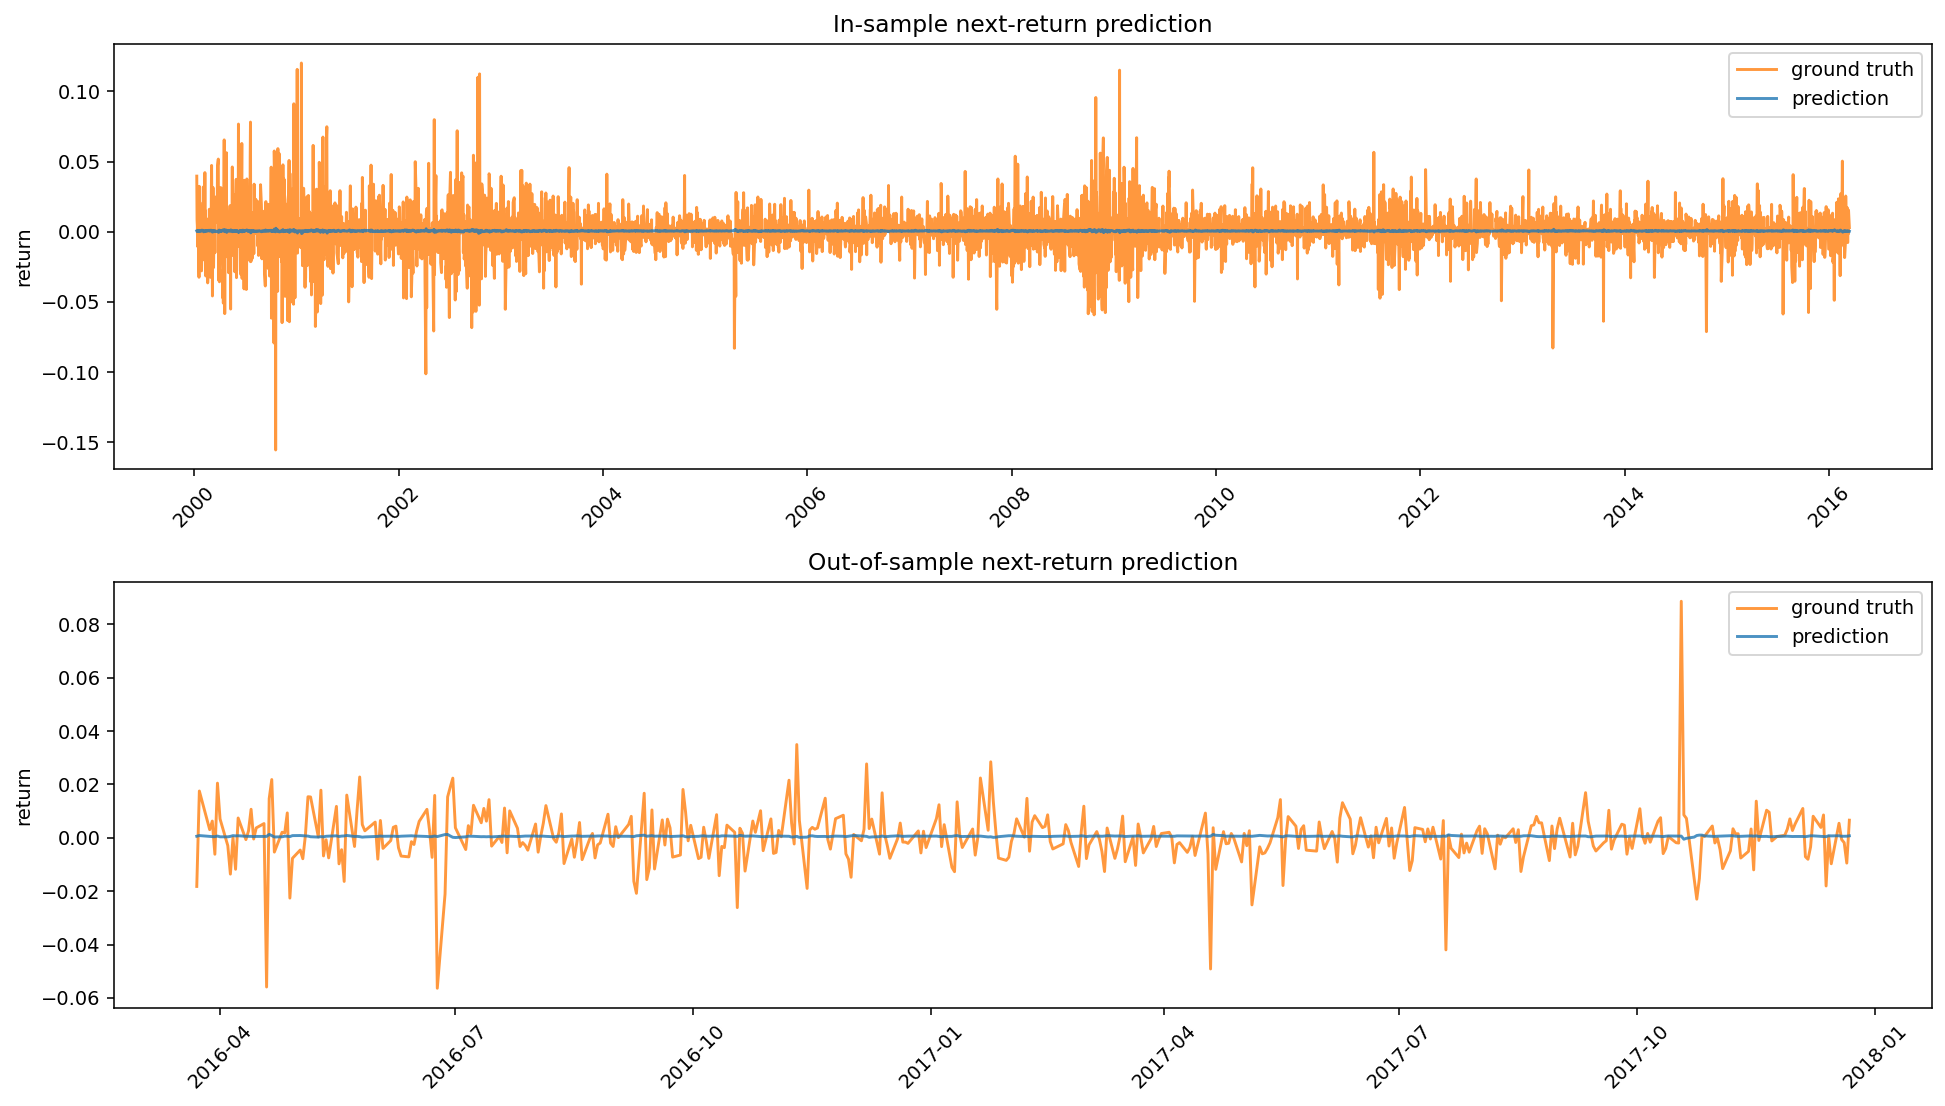

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
for ax, dates, truth, predictions, title in [
    (axes[0], train_dates[:, -1], train_truth, train_predictions, 'In-sample next-return prediction'),
    (axes[1], valid_dates[:, -1], valid_truth, valid_predictions, 'Out-of-sample next-return prediction')]:
    
    ax.plot(dates, truth, label='ground truth', color='C1', alpha=0.8)
    ax.plot(dates, predictions, label='prediction', color='C0', alpha=0.8)
    ax.set_title(title)
    ax.set_ylabel('return')
    ax.legend()
    
    for tick in ax.get_xticklabels():
        tick.set_rotation(45)
        
plt.tight_layout()

## 6. Turn Predictions into Trading Signals

We first collect the model forecasts in a data frame aligned to the last observed trading day of each input sequence. That is the latest date at which all model inputs are known, so it is the correct decision point for the backtest.

In [20]:
signal_data = pd.DataFrame({'PREDICTION': valid_predictions, 'TARGET': valid_truth, 'PREDICTED_RETURN_DATE': pd.to_datetime(valid_dates[:, -1])}, index=pd.to_datetime(valid_dates[:, -2]))
signal_data.index.name = 'SIGNAL_DATE'
signal_data.head()

,PREDICTION,TARGET,PREDICTED_RETURN_DATE
SIGNAL_DATE,,,
2016-03-22,0.000583,-0.018231,2016-03-23
2016-03-23,0.000837,0.017538,2016-03-24
2016-03-24,0.000527,0.003042,2016-03-28
2016-03-28,0.000449,0.006267,2016-03-29
2016-03-29,0.000429,-0.006162,2016-03-30


We can now convert the forecast into a trading rule. A positive predicted return becomes a long signal, a negative predicted return becomes a short signal, and we remove any duplicate timestamps before the later backtest.

In [21]:
signal_data['SIGNAL'] = np.where(signal_data['PREDICTION'] > 0.0, 1.0, -1.0)
signal_data = signal_data[~signal_data.index.duplicated(keep='last')]
signal_data.head()

,PREDICTION,TARGET,PREDICTED_RETURN_DATE,SIGNAL
SIGNAL_DATE,,,,
2016-03-22,0.000583,-0.018231,2016-03-23,1.0
2016-03-23,0.000837,0.017538,2016-03-24,1.0
2016-03-24,0.000527,0.003042,2016-03-28,1.0
2016-03-28,0.000449,0.006267,2016-03-29,1.0
2016-03-29,0.000429,-0.006162,2016-03-30,1.0


## 7. Backtest the LSTM Strategy



To evaluate the practical value of the model output, we backtest the generated signals over the out-of-sample period. We begin by preparing the closing-price series that will be used as the market input for both strategies.

In [22]:
stock_market_data = stock_data[['Close']].rename(columns={'Close': 'IBM'})
stock_market_data = stock_market_data.loc[signal_data.index.min():signal_data.index.max()]
stock_market_data.head()

Price,IBM
2016-03-22,92.334785
2016-03-23,90.651428
2016-03-24,92.241249
2016-03-28,92.521843
2016-03-29,93.101685


Next, we define a small trading rule that reads the signal for the current date and translates it into a portfolio weight for IBM.

In [23]:
class SignalStrategy(bt.Algo):
    def __init__(self, signals):
        self.signals = signals

    def __call__(self, target):
        if target.now in self.signals.index:
            target.temp['weights'] = {'IBM': float(self.signals.loc[target.now])}
        return True

With the market data and trading rule in place, we can instantiate the LSTM-driven strategy, define the buy-and-hold benchmark, and execute both backtests.

In [24]:
lstm_strategy = bt.Strategy('lstm',[bt.algos.SelectAll(), SignalStrategy(signal_data['SIGNAL']), bt.algos.Rebalance()])

base_signals = signal_data['SIGNAL'].copy()
base_signals[:] = 1.0
base_strategy = bt.Strategy('buy_and_hold',[bt.algos.SelectAll(), SignalStrategy(base_signals), bt.algos.Rebalance()])

backtest_lstm = bt.Backtest(lstm_strategy, stock_market_data)

backtest_base = bt.Backtest(base_strategy, stock_market_data)

backtest_results = bt.run(backtest_lstm, backtest_base)
backtest_results.display()

Stat                 lstm        buy_and_hold
-------------------  ----------  --------------
Start                2016-03-21  2016-03-21
End                  2017-12-21  2017-12-21
Risk-free rate       0.00%       0.00%

Total Return         5.79%       9.20%
Daily Sharpe         0.28        0.38
Daily Sortino        0.40        0.55
CAGR                 3.26%       5.15%
Max Drawdown         -21.65%     -21.65%
Calmar Ratio         0.15        0.24

MTD                  -1.60%      -1.60%
3m                   2.05%       5.34%
6m                   -2.59%      0.55%
YTD                  -8.15%      -5.19%
1Y                   -8.89%      -5.95%
3Y (ann.)            -           -
5Y (ann.)            -           -
10Y (ann.)           -           -
Since Incep. (ann.)  3.26%       5.15%

Daily Sharpe         0.28        0.38
Daily Sortino        0.40        0.55
Daily Mean (ann.)    4.56%       6.36%
Daily Vol (ann.)     16.59%      16.59%
Daily Skew           0.44        0.42
Daily Ku

After running both strategies, we inspect the aggregated performance table and then focus on the relative equity curves of the LSTM strategy and the passive benchmark.

The next cell visualizes how both portfolios evolved over time and also reports the buy-and-hold return over the same evaluation window.

Buy-and-hold return over the evaluation window: 9.20%


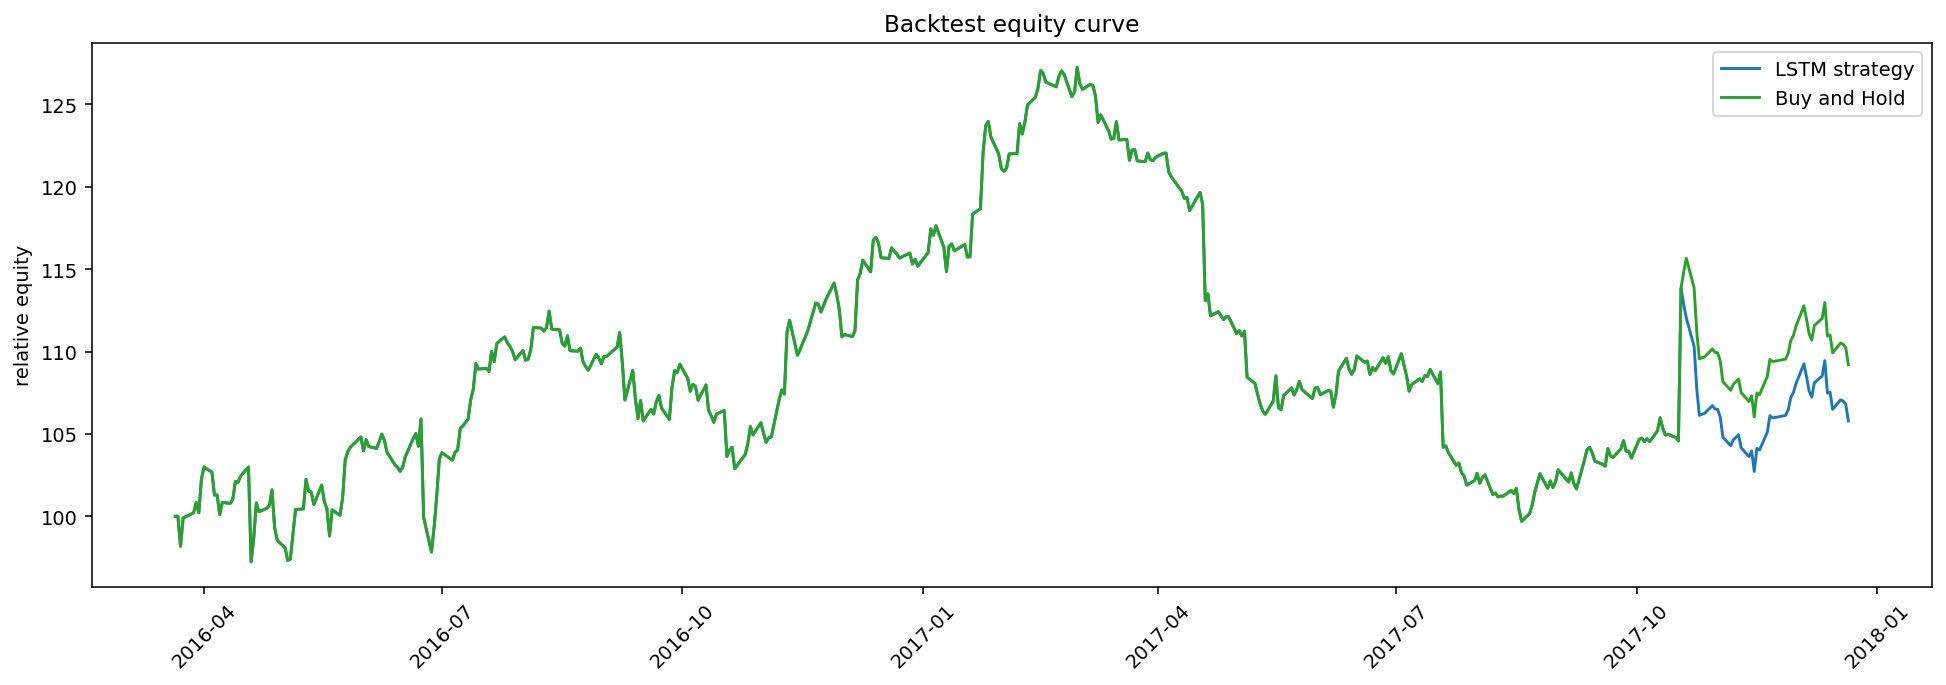

In [ ]:
lstm_equity = backtest_lstm.strategy.prices.to_frame(name='LSTM strategy')
base_equity = backtest_base.strategy.prices.to_frame(name='Buy and Hold')
buy_hold_return = (stock_market_data['IBM'].iloc[-1] - stock_market_data['IBM'].iloc[0]) / stock_market_data['IBM'].iloc[0]

fig, ax = plt.subplots(1, 1, figsize=(14, 5))
for label, frame, color in [('LSTM strategy', lstm_equity, 'C0'), ('Buy and Hold', base_equity, 'C2')]:
    ax.plot(frame.index, frame.iloc[:, 0], label=label, color=color)

ax.set(title='Backtest equity curve', ylabel='relative equity')
ax.legend()
for tick in ax.get_xticklabels():
    tick.set_rotation(45)

plt.tight_layout()
print(f'Buy-and-hold return over the evaluation window: {buy_hold_return:.2%}')

## 8. Summary



In this notebook, we built a complete LSTM-based workflow for financial time-series forecasting and strategy evaluation. Starting from daily IBM closing prices, we constructed a return series, transformed it into rolling sequences, used an LSTM network to generate one-step-ahead forecasts, and mapped those forecasts to long and short trading signals.



We then evaluated the resulting strategy in a historical backtest and compared it with a buy-and-hold benchmark. This illustrates an important idea in applied machine learning: model quality should be assessed not only through predictions, but also through how those predictions support the downstream task of interest.



**Further Exploration**



1. Change the sequence length and study how the prediction quality and signal behavior change.

2. Introduce a threshold around zero so that the model only takes a position when the predicted return is sufficiently strong.

3. Compare the LSTM strategy with additional baselines, such as a moving-average crossover or a long-only rule with periodic rebalancing.